In [1]:
import matplotlib.pyplot as plt
import numpy as np

from HH_model import I_Na, I_K, I_L
from HH_model import HH_Neuron

#Ignores RunTimeWarnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
test=HH_Neuron(I=280)
res=test.run(tf=12,dt=0.001,tt=0)

t=res.t
V,n,m,h=res.y

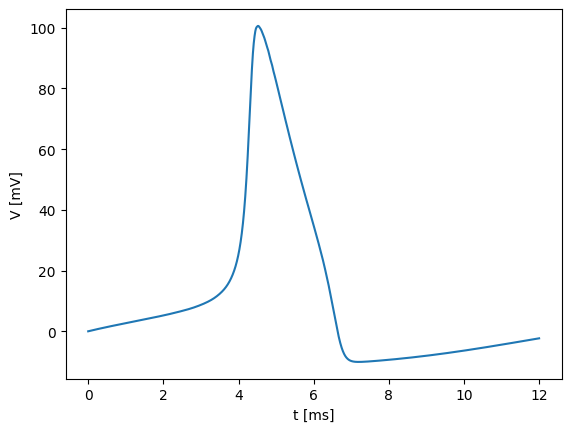

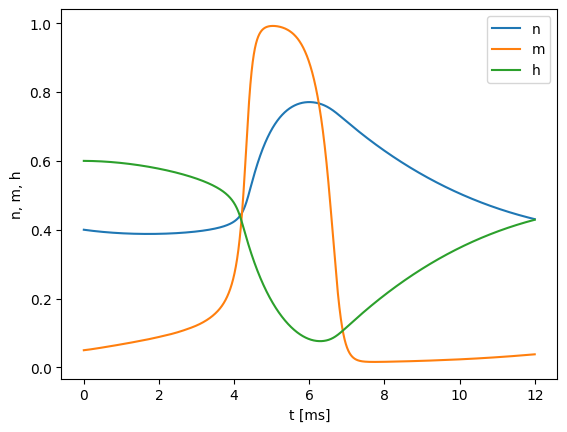

In [3]:
plt.plot(t,V)
plt.xlabel("t [ms]")
plt.ylabel("V [mV]")
#plt.savefig("V_fire_I280.pdf",bbox_inches="tight")
plt.show()

plt.plot(t,n,label="n")
plt.plot(t,m,label="m")
plt.plot(t,h,label="h")
plt.legend(loc="upper right")
plt.xlabel("t [ms]")
plt.ylabel("n, m, h")
#plt.savefig("gates_I280.pdf",bbox_inches="tight")
plt.show()

In [4]:
test=HH_Neuron(I=280)
res=test.run(tf=100,dt=0.001)

t=res.t
V,n,m,h=res.y

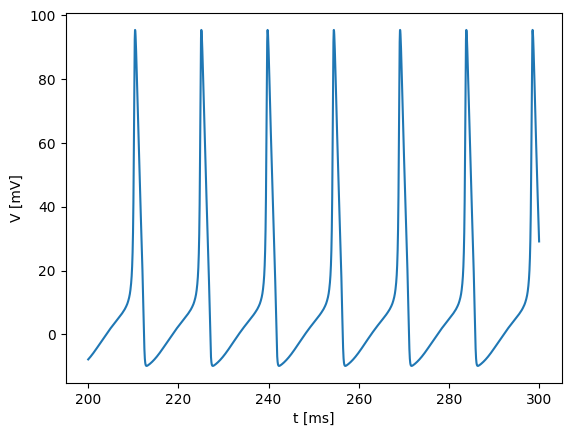

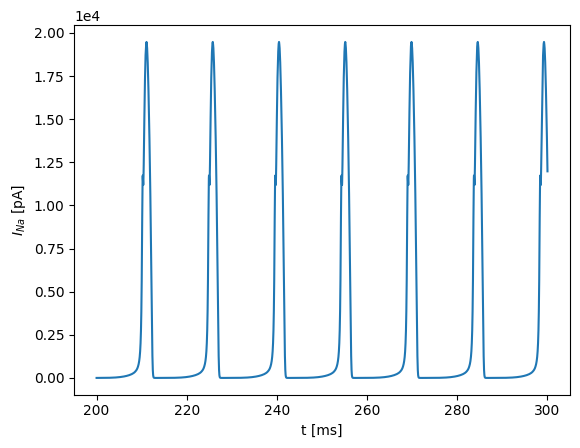

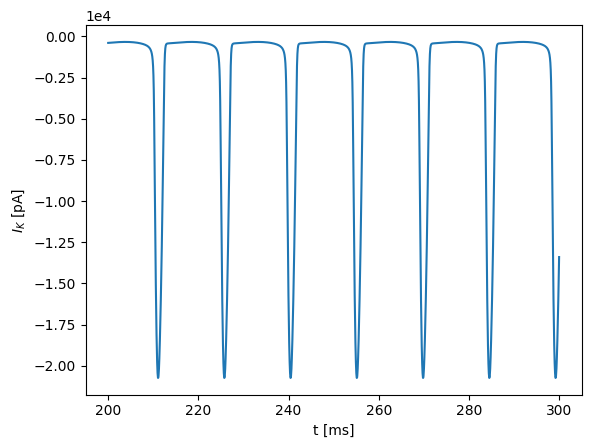

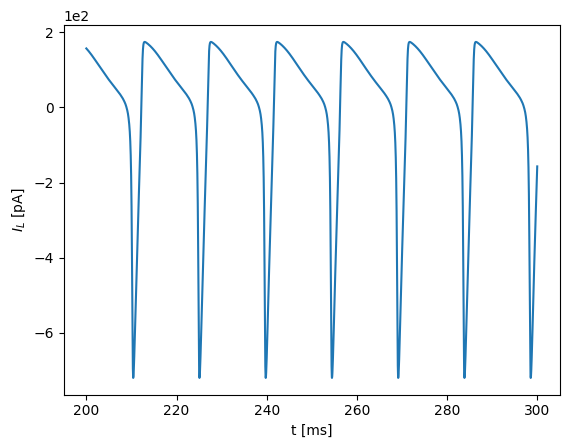

In [5]:
plt.plot(t,V)
plt.xlabel("t [ms]")
plt.ylabel("V [mV]")
#plt.savefig("V_I280.pdf",bbox_inches="tight")
plt.show()

plt.plot(t,I_Na(m=m,h=h,V=V),label=f"$I_{{Na}}$")
plt.xlabel("t [ms]")
plt.ylabel(r"$I_{Na}$ [pA]")
plt.ticklabel_format(axis="y", style='sci', scilimits=(0, 0))
#plt.savefig("I_Na_I280.pdf",bbox_inches="tight")
plt.show()

plt.plot(t,I_K(n=n,V=V),label=f"$I_K$")
plt.xlabel("t [ms]")
plt.ylabel(f"$I_K$ [pA]")
plt.ticklabel_format(axis="y", style='sci', scilimits=(0, 0))
#plt.savefig("I_K_I280.pdf",bbox_inches="tight")
plt.show()

plt.plot(t,I_L(V=V),label=f"$I_L$")
plt.xlabel("t [ms]")
plt.ylabel(f"$I_L$ [pA]")
plt.ticklabel_format(axis="y", style='sci', scilimits=(0, 0))
#plt.savefig("I_L_I280.pdf",bbox_inches="tight")
plt.show()

In [6]:
test=HH_Neuron(I=350)
res=test.run(tf=100,dt=0.001)

t=res.t
V,n,m,h=res.y

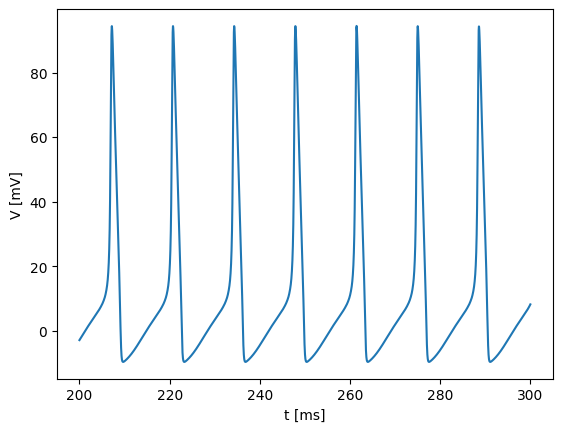

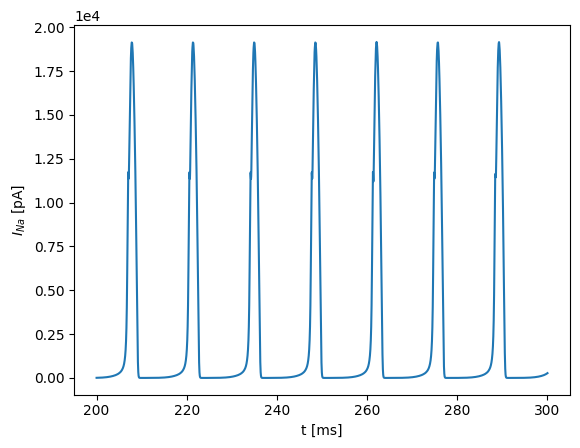

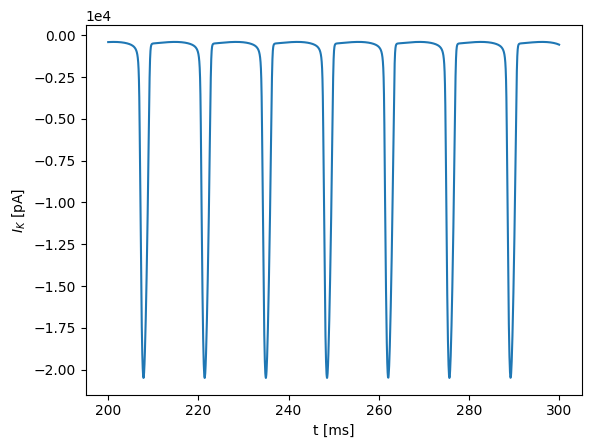

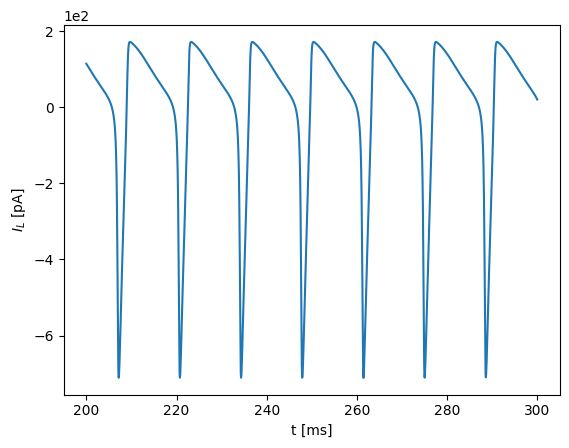

In [7]:
plt.plot(t,V)
plt.xlabel("t [ms]")
plt.ylabel("V [mV]")
#plt.savefig("V_I350.pdf",bbox_inches="tight")
plt.show()

plt.plot(t,I_Na(m=m,h=h,V=V),label=f"$I_{{Na}}$")
plt.xlabel("t [ms]")
plt.ylabel(r"$I_{Na}$ [pA]")
plt.ticklabel_format(axis="y", style='sci', scilimits=(0, 0))
#plt.savefig("I_Na_I350.pdf",bbox_inches="tight")
plt.show()

plt.plot(t,I_K(n=n,V=V),label=f"$I_K$")
plt.xlabel("t [ms]")
plt.ylabel(f"$I_K$ [pA]")
plt.ticklabel_format(axis="y", style='sci', scilimits=(0, 0))
#plt.savefig("I_K_I350.pdf",bbox_inches="tight")
plt.show()

plt.plot(t,I_L(V=V),label=f"$I_L$")
plt.xlabel("t [ms]")
plt.ylabel(f"$I_L$ [pA]")
plt.ticklabel_format(axis="y", style='sci', scilimits=(0, 0))
#plt.savefig("I_L_I350.pdf",bbox_inches="tight")
plt.show()

# Frequencies

In [8]:
I0=np.arange(150,351,1)

In [9]:
f=np.empty((len(I0),2))
model=HH_Neuron(I0[0])

for i in range(len(I0)):
    f[i]=model.pulsefreq(I0[i],min_peaks=5,tf=1000,dt=0.01)

In [10]:
f_inv=np.empty((len(I0),2))
model=HH_Neuron(I0[-1])

for i in range(1,len(I0)+1):
    f_inv[i-1]=model.pulsefreq(I0[-i],min_peaks=5,tf=1000,dt=0.01)

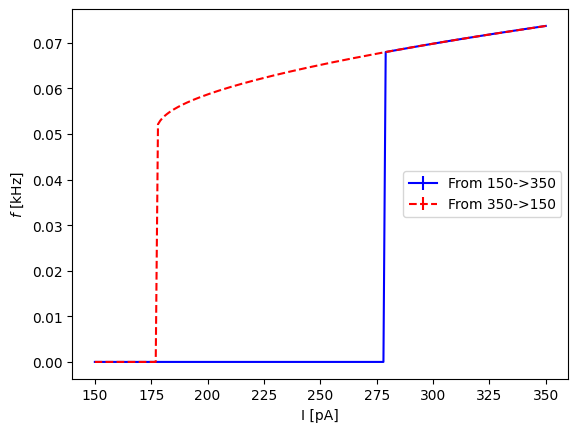

In [11]:
plt.errorbar(I0,f[:,0],yerr=f[:,1],fmt="b-",label="From 150->350")
plt.errorbar(I0[::-1],f_inv[:,0],yerr=f_inv[:,1],fmt="r--",label="From 350->150")
plt.xlabel("I [pA]")
plt.ylabel(f"$f$ [kHz]")
plt.legend(loc="center right")
#plt.savefig("pulsfreq.pdf",bbox_inches="tight")
plt.show()